# Customer Segmentation & Churn Analysis

**Bonus Project C | Intermediate-Advanced | KMeans + Logistic Regression**

---

A telecom company wants two things at once: to understand the natural groups (segments) its customers fall into, and to predict which customers are likely to churn. This project combines unsupervised and supervised learning in a single pipeline.

**Business Objective:** Segment customers into meaningful groups using clustering, then predict churn within that context, so marketing and retention teams can target each segment with tailored strategies.

**Dataset:** Telco Customer Churn (Kaggle - blastchar) | 7,043 customers, 21 features

**Libraries:** pandas, numpy, matplotlib, seaborn, scikit-learn

## 1. Setup & Data Loading

Let us load the required libraries and the Telco Customer Churn dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.figsize': (10, 6), 'figure.dpi': 120})

df = pd.read_csv('../Dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Dataset shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Data Inspection

Let us examine the dataset structure, data types, missing values, and basic statistics.

In [2]:
print('=== DATASET INFO ===')
df.info()
print()
print('=== MISSING VALUES ===')
print(df.isnull().sum())
print()
print('=== BASIC STATISTICS (numeric) ===')
df.describe()

=== DATASET INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null 

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [3]:
print('=== TARGET DISTRIBUTION ===')
print(df['Churn'].value_counts())
churn_rate = df['Churn'].value_counts(normalize=True)['Yes']
print(f'Churn rate: {churn_rate:.2%}')
print()
print('=== DTYPES ===')
print(df.dtypes)
print()
print('=== UNIQUE VALUES PER CATEGORICAL COLUMN ===')
for col in df.select_dtypes(include='object').columns:
    print(f'{col}: {df[col].nunique()} unique values')

=== TARGET DISTRIBUTION ===
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn rate: 26.54%

=== DTYPES ===
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

=== UNIQUE VALUES PER CATEGORICAL COLUMN ===
customerID: 7043 unique values
gender: 2 unique values
Partner: 2 unique values
Dependents: 2 unique values
PhoneService: 2 unique values
MultipleLines: 3 unique values
InternetService: 3 unique values
OnlineSecurity: 3 unique values

## 3. Data Cleaning

Tasks:
1. Convert `TotalCharges` from text to numeric (blank values for new customers)
2. Drop `customerID` (non-informative identifier)
3. Standardize 'No internet service' / 'No phone service' labels into 'No'
4. Check for duplicate rows

In [4]:
df_clean = df.copy()

# 1. Convert TotalCharges to numeric
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
null_count = df_clean['TotalCharges'].isnull().sum()
print(f'TotalCharges null after conversion: {null_count}')

df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0)
print(f'TotalCharges null after fill: {df_clean["TotalCharges"].isnull().sum()}')

# 2. Drop customerID
df_clean = df_clean.drop(columns=['customerID'])
print(f'Shape after dropping customerID: {df_clean.shape}')

# 3. Standardize service labels
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in service_cols:
    df_clean[col] = df_clean[col].replace('No internet service', 'No')

df_clean['MultipleLines'] = df_clean['MultipleLines'].replace('No phone service', 'No')

# 4. Check for duplicates
print(f'Duplicate rows: {df_clean.duplicated().sum()}')
print()
print(f'Cleaned dataset shape: {df_clean.shape}')
df_clean.head()

TotalCharges null after conversion: 11
TotalCharges null after fill: 0
Shape after dropping customerID: (7043, 20)
Duplicate rows: 22

Cleaned dataset shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4. Exploratory Data Analysis (EDA)

Before building models, let us understand the data visually.

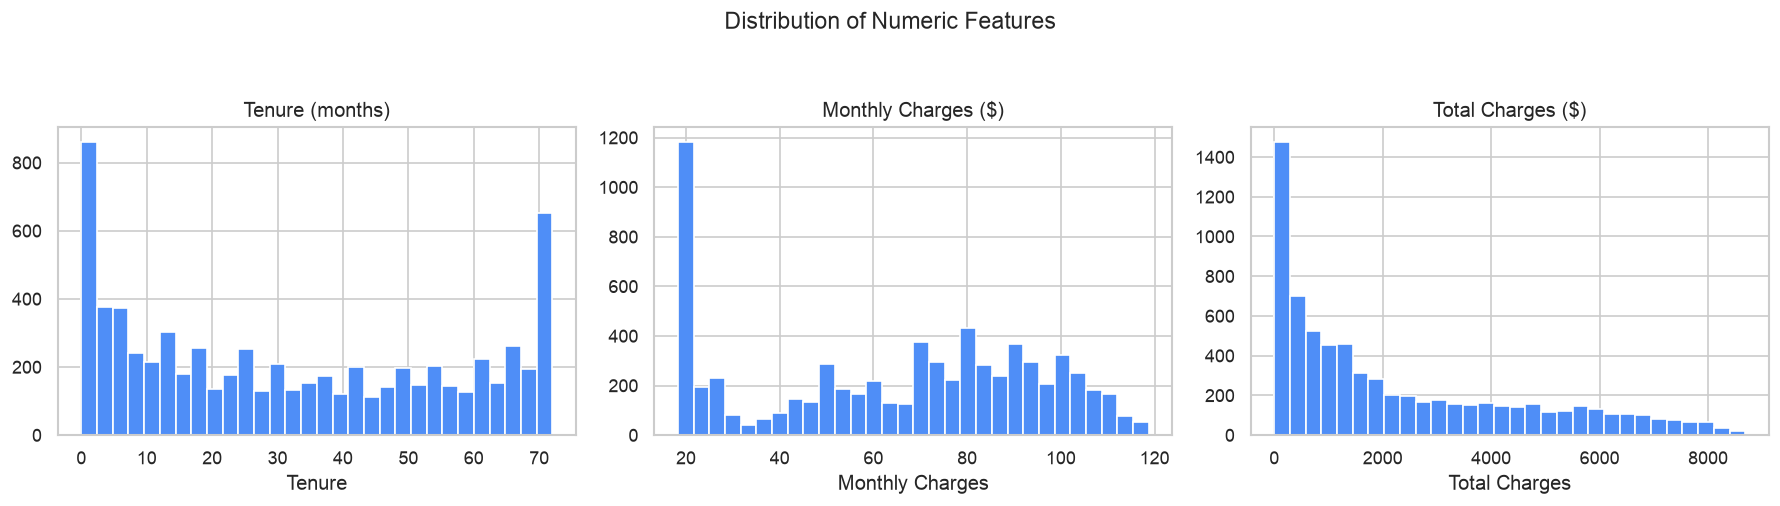

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribution of Numeric Features', fontsize=14, y=1.05)

axes[0].hist(df_clean['tenure'], bins=30, color='#4f8ef7', edgecolor='white')
axes[0].set_title('Tenure (months)')
axes[0].set_xlabel('Tenure')

axes[1].hist(df_clean['MonthlyCharges'], bins=30, color='#4f8ef7', edgecolor='white')
axes[1].set_title('Monthly Charges ($)')
axes[1].set_xlabel('Monthly Charges')

axes[2].hist(df_clean['TotalCharges'], bins=30, color='#4f8ef7', edgecolor='white')
axes[2].set_title('Total Charges ($)')
axes[2].set_xlabel('Total Charges')

plt.tight_layout()
plt.savefig('../Images/eda_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

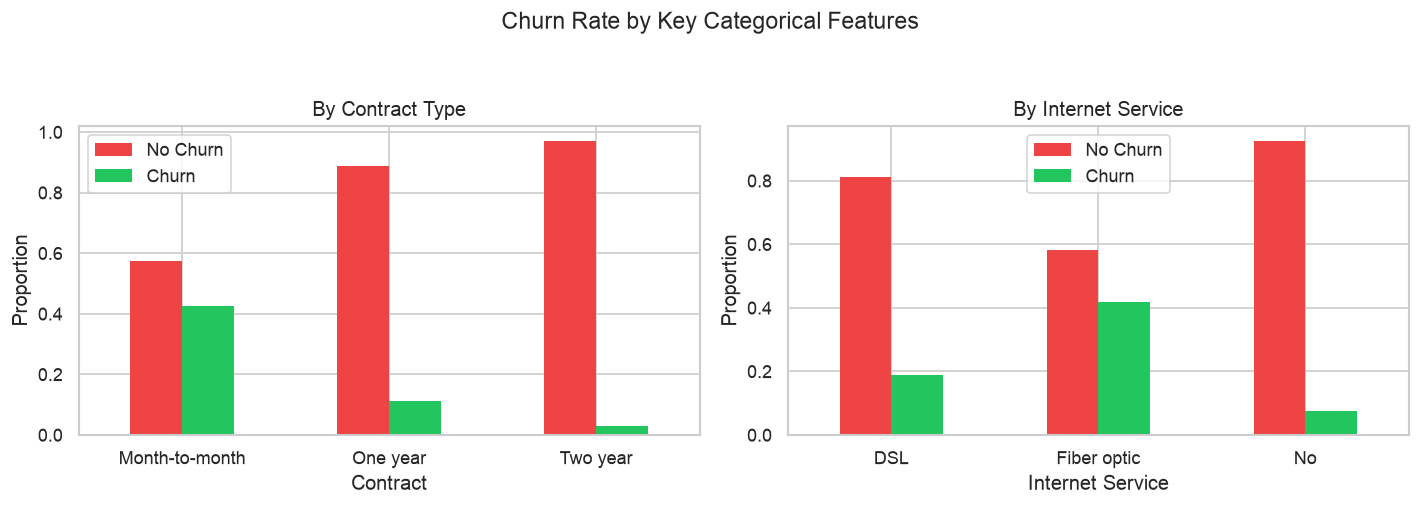

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Churn Rate by Key Categorical Features', fontsize=14, y=1.05)

contract_rates = df_clean.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
contract_rates.plot(kind='bar', ax=axes[0], color=['#ef4444', '#22c55e'], edgecolor='none')
axes[0].set_title('By Contract Type')
axes[0].set_xlabel('Contract')
axes[0].set_ylabel('Proportion')
axes[0].tick_params(rotation=0)
axes[0].legend(['No Churn', 'Churn'])

internet_rates = df_clean.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack()
internet_rates.plot(kind='bar', ax=axes[1], color=['#ef4444', '#22c55e'], edgecolor='none')
axes[1].set_title('By Internet Service')
axes[1].set_xlabel('Internet Service')
axes[1].set_ylabel('Proportion')
axes[1].tick_params(rotation=0)
axes[1].legend(['No Churn', 'Churn'])

plt.tight_layout()
plt.savefig('../Images/eda_churn_by_category.png', dpi=120, bbox_inches='tight')
plt.show()

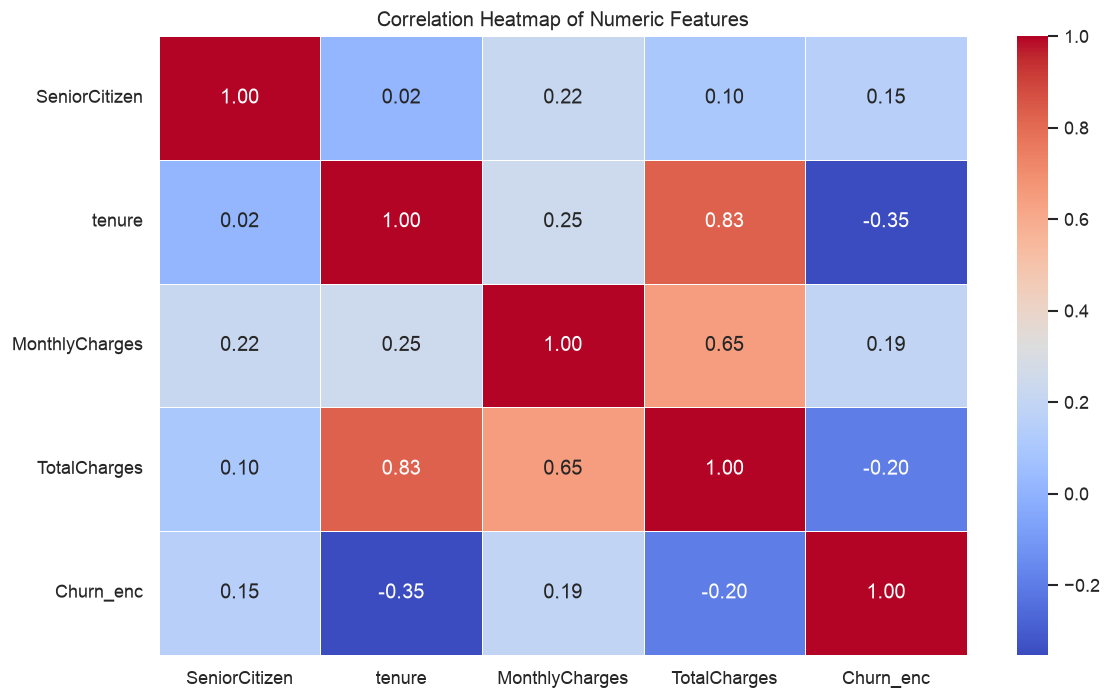

In [7]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
df_corr = df_clean.copy()
df_corr['Churn_enc'] = (df_corr['Churn'] == 'Yes').astype(int)
corr_cols = [c for c in numeric_cols] + ['Churn_enc']

plt.figure(figsize=(10, 6))
corr = df_corr[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.savefig('../Images/eda_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

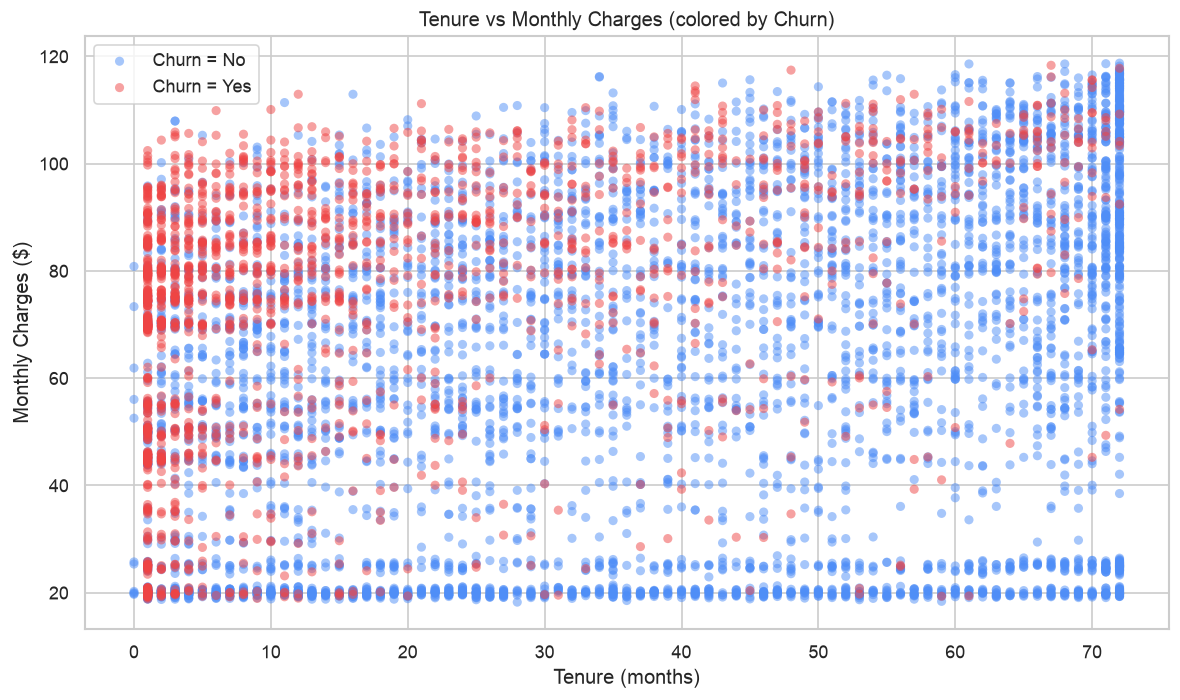

In [8]:
plt.figure(figsize=(10, 6))
colors = {'No': '#4f8ef7', 'Yes': '#ef4444'}
for churn_val in ['No', 'Yes']:
    subset = df_clean[df_clean['Churn'] == churn_val]
    plt.scatter(subset['tenure'], subset['MonthlyCharges'],
                c=colors[churn_val], label=f'Churn = {churn_val}',
                alpha=0.5, edgecolors='none', s=30)

plt.xlabel('Tenure (months)')
plt.ylabel('Monthly Charges ($)')
plt.title('Tenure vs Monthly Charges (colored by Churn)')
plt.legend()
plt.tight_layout()
plt.savefig('../Images/eda_tenure_vs_monthly.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Feature Engineering

### For Clustering

We will scale `tenure`, `MonthlyCharges`, and `TotalCharges`.

In [9]:
cluster_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_cluster = df_clean[cluster_features].copy()

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)
X_cluster_scaled = pd.DataFrame(X_cluster_scaled, columns=cluster_features)

print('Scaled cluster features:')
print(X_cluster_scaled.describe())

Scaled cluster features:
             tenure  MonthlyCharges  TotalCharges
count  7.043000e+03    7.043000e+03  7.043000e+03
mean  -2.421273e-17   -6.406285e-17 -3.783239e-17
std    1.000071e+00    1.000071e+00  1.000071e+00
min   -1.318165e+00   -1.545860e+00 -1.005780e+00
25%   -9.516817e-01   -9.725399e-01 -8.299464e-01
50%   -1.372744e-01    1.857327e-01 -3.905282e-01
75%    9.214551e-01    8.338335e-01  6.648034e-01
max    1.613701e+00    1.794352e+00  2.825806e+00


## 6. Customer Segmentation with KMeans

We will use the elbow method to choose the optimal number of clusters (k), then assign each customer to a segment.

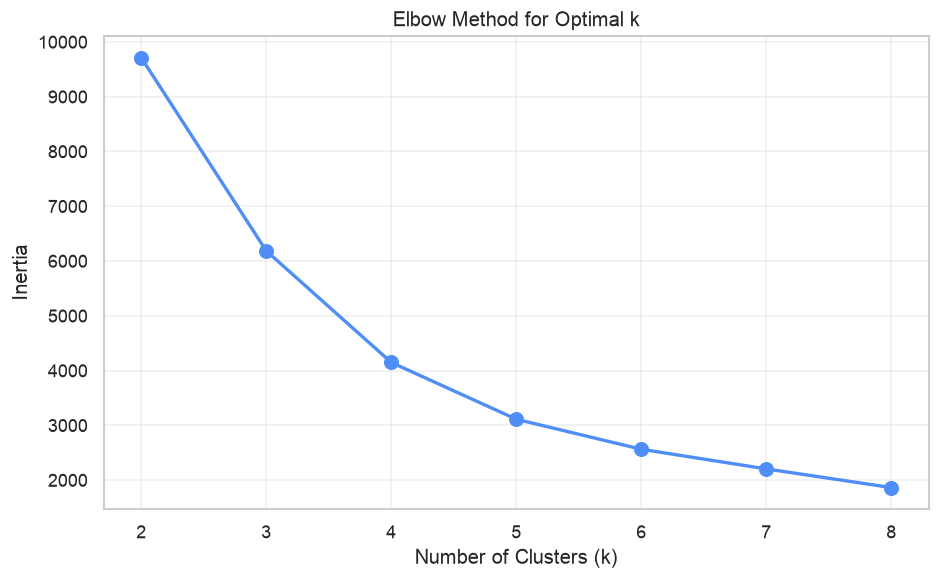

Inertia values:
  k=2: inertia=9712.11
  k=3: inertia=6186.19
  k=4: inertia=4148.48
  k=5: inertia=3111.40
  k=6: inertia=2562.93
  k=7: inertia=2204.45
  k=8: inertia=1863.21


In [10]:
inertia = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', color='#4f8ef7', linewidth=2, markersize=8)
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../Images/elbow_curve.png', dpi=120, bbox_inches='tight')
plt.show()

print('Inertia values:')
for k, inert in zip(K_range, inertia):
    print(f'  k={k}: inertia={inert:.2f}')

### Choosing k

Looking at the elbow curve, the inertia drops sharply up to k=4 and then levels off. We choose **k=4** as it provides a good balance between capturing meaningful segments and keeping the model interpretable.

In [11]:
k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

print('Cluster distribution:')
print(df_clean['Cluster'].value_counts().sort_index())

Cluster distribution:
Cluster
0    1703
1    1904
2    2276
3    1160
Name: count, dtype: int64


In [12]:
cluster_profile = df_clean.groupby('Cluster').agg({
    'tenure': 'mean',
    'MonthlyCharges': 'mean',
    'TotalCharges': 'mean',
    'Churn': lambda x: (x == 'Yes').mean()
}).round(2)

cluster_profile['Churn Rate'] = cluster_profile['Churn']
cluster_profile = cluster_profile.drop(columns=['Churn'])
cluster_profile['Size'] = df_clean.groupby('Cluster').size().values
cluster_profile['Size %'] = (cluster_profile['Size'] / cluster_profile['Size'].sum() * 100).round(1)

print('=== CLUSTER PROFILES ===')
print(cluster_profile)

segment_names = {
    0: 'High-Value Loyal',
    1: 'Low-Engagement New',
    2: 'Premium Short-Term',
    3: 'Mid-Value At-Risk'
}
df_clean['Segment'] = df_clean['Cluster'].map(segment_names)
print()
print('Segment assignments:')
print(df_clean['Segment'].value_counts())

=== CLUSTER PROFILES ===
         tenure  MonthlyCharges  TotalCharges  Churn Rate  Size  Size %
Cluster                                                                
0         10.21           31.78        302.15        0.25  1703    24.2
1         59.53           93.31       5548.65        0.15  1904    27.0
2         15.42           80.78       1251.17        0.48  2276    32.3
3         53.57           34.91       1835.62        0.05  1160    16.5

Segment assignments:
Segment
Premium Short-Term    2276
Low-Engagement New    1904
High-Value Loyal      1703
Mid-Value At-Risk     1160
Name: count, dtype: int64


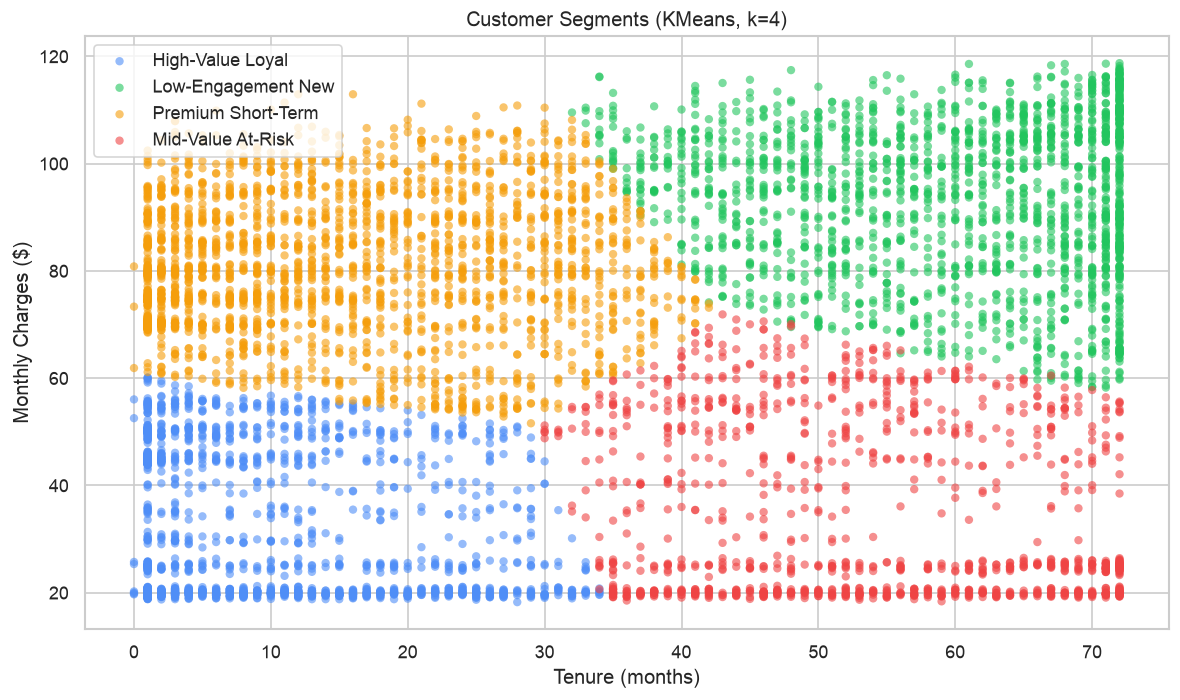

In [13]:
plt.figure(figsize=(10, 6))
cluster_colors = ['#4f8ef7', '#22c55e', '#f59e0b', '#ef4444']
for cluster in range(k_optimal):
    subset = df_clean[df_clean['Cluster'] == cluster]
    plt.scatter(subset['tenure'], subset['MonthlyCharges'],
                c=cluster_colors[cluster],
                label=segment_names[cluster],
                alpha=0.6, edgecolors='none', s=25)

plt.xlabel('Tenure (months)')
plt.ylabel('Monthly Charges ($)')
plt.title(f'Customer Segments (KMeans, k={k_optimal})')
plt.legend()
plt.tight_layout()
plt.savefig('../Images/cluster_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

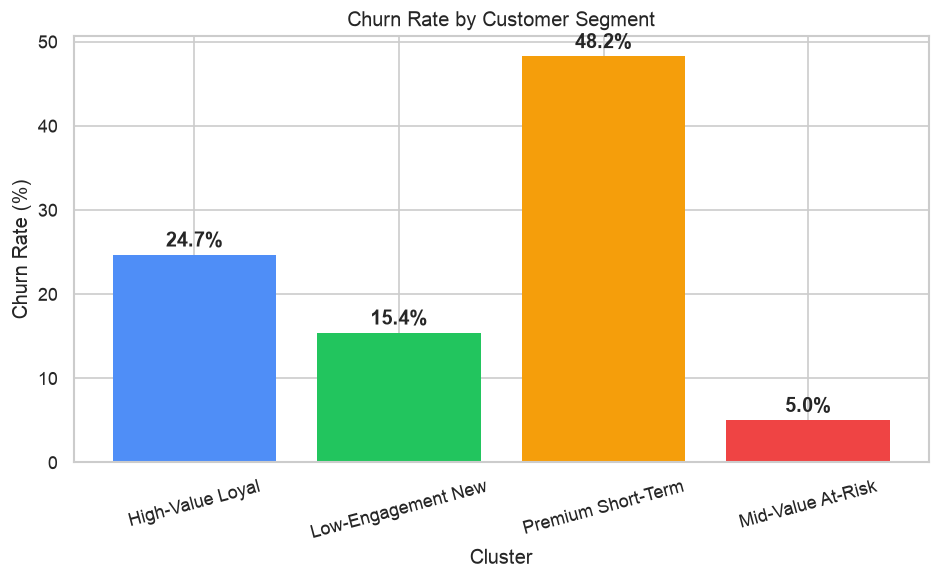

In [14]:
plt.figure(figsize=(8, 5))
churn_by_cluster = df_clean.groupby('Cluster')['Churn'].apply(
    lambda x: (x == 'Yes').mean()
) * 100
bars = plt.bar(churn_by_cluster.index, churn_by_cluster.values,
               color=cluster_colors, edgecolor='none')
plt.title('Churn Rate by Customer Segment')
plt.xlabel('Cluster')
plt.ylabel('Churn Rate (%)')
plt.xticks(range(k_optimal),
           [segment_names[i] for i in range(k_optimal)],
           rotation=15)
for bar, val in zip(bars, churn_by_cluster.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../Images/churn_by_cluster.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Feature Engineering for Churn Prediction

Now we will prepare the data for the Logistic Regression churn model:
1. One-hot encode categorical columns
2. Add the cluster label as a feature
3. Split into train/test sets

In [15]:
df_model = df_clean.copy()

df_model['Churn_enc'] = (df_model['Churn'] == 'Yes').astype(int)

cat_cols = df_model.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['Churn']]

print(f'Categorical columns to encode: {cat_cols}')

df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)
print(f'Shape after encoding: {df_model.shape}')

feature_cols = [c for c in df_model.columns if c not in ['Churn', 'Churn_enc', 'Segment']]
X = df_model[feature_cols]
y = df_model['Churn_enc']

print(f'Feature matrix shape: {X.shape}')
print(f'Target distribution:')
print(y.value_counts())

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Segment']
Shape after encoding: (7043, 29)
Feature matrix shape: (7043, 27)
Target distribution:
Churn_enc
0    5174
1    1869
Name: count, dtype: int64


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set size: {X_train.shape[0]}')
print(f'Test set size: {X_test.shape[0]}')
print(f'Train churn rate: {y_train.mean():.2%}')
print(f'Test churn rate: {y_test.mean():.2%}')

Training set size: 5634
Test set size: 1409
Train churn rate: 26.54%
Test churn rate: 26.54%


## 8. Churn Prediction with Logistic Regression

We will train a Logistic Regression model to predict churn, including the cluster label as a feature.

In [17]:
logreg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
y_proba = logreg.predict_proba(X_test)[:, 1]

print('Model Parameters:')
print(f'  Solver    : {logreg.solver}')
print(f'  Max iter  : {logreg.max_iter}')
print(f'  Features  : {len(logreg.coef_[0])}')
print(f'  Class weight: balanced')

Model Parameters:
  Solver    : lbfgs
  Max iter  : 1000
  Features  : 27
  Class weight: balanced


In [18]:
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
cm        = confusion_matrix(y_test, y_pred)

print('='*50)
print('     LOGISTIC REGRESSION EVALUATION')
print('='*50)
print(f'  Accuracy : {accuracy:.4f}  ({accuracy:.2%})')
print(f'  Precision: {precision:.4f}  ({precision:.2%})')
print(f'  Recall   : {recall:.4f}  ({recall:.2%})')
print(f'  F1 Score : {f1:.4f}  ({f1:.2%})')
print('='*50)
print()
print('Full Classification Report:')
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

     LOGISTIC REGRESSION EVALUATION
  Accuracy : 0.7402  (74.02%)
  Precision: 0.5068  (50.68%)
  Recall   : 0.7995  (79.95%)
  F1 Score : 0.6203  (62.03%)

Full Classification Report:
              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1035
       Churn       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



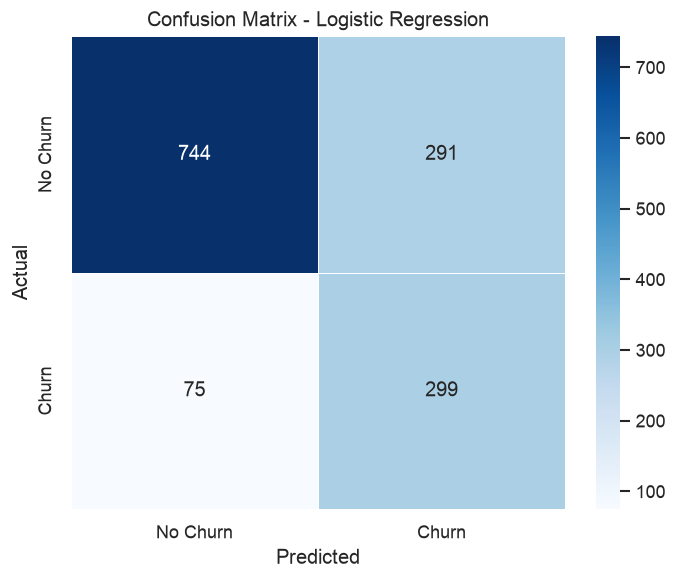

In [19]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            linewidths=0.5)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.savefig('../Images/confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

=== TOP 10 MOST IMPORTANT FEATURES ===
                       Feature  Coefficient  Abs_Coefficient
             Contract_Two year    -1.405647         1.405647
              PhoneService_Yes    -0.726135         0.726135
             Contract_One year    -0.710828         0.710828
   InternetService_Fiber optic     0.525072         0.525072
            OnlineSecurity_Yes    -0.489455         0.489455
    Segment_Premium Short-Term    -0.478324         0.478324
            InternetService_No    -0.422325         0.422325
     Segment_Mid-Value At-Risk     0.406121         0.406121
               TechSupport_Yes    -0.404501         0.404501
PaymentMethod_Electronic check     0.379929         0.379929


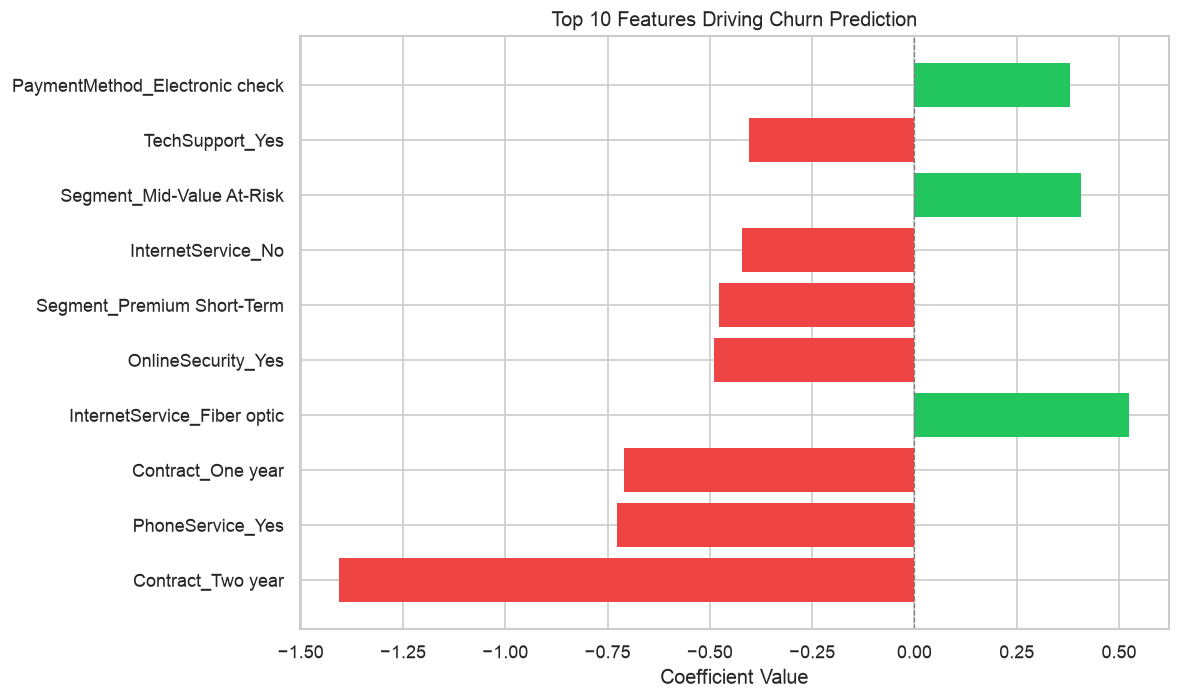

In [20]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': logreg.coef_[0],
    'Abs_Coefficient': np.abs(logreg.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print('=== TOP 10 MOST IMPORTANT FEATURES ===')
print(coef_df.head(10).to_string(index=False))

top_n = 10
top_features = coef_df.head(top_n)
bar_colors = ['#22c55e' if c > 0 else '#ef4444' for c in top_features['Coefficient']]

plt.figure(figsize=(10, 6))
plt.barh(range(top_n), top_features['Coefficient'], color=bar_colors, edgecolor='none')
plt.yticks(range(top_n), top_features['Feature'])
plt.xlabel('Coefficient Value')
plt.title('Top 10 Features Driving Churn Prediction')
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('../Images/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Segment-Level Churn Summary

Now let us combine the clustering and churn analysis into a unified business story.

In [21]:
segment_summary = df_clean.groupby(['Cluster', 'Segment']).agg({
    'tenure': 'mean',
    'MonthlyCharges': 'mean',
    'TotalCharges': 'mean',
    'Churn': lambda x: (x == 'Yes').mean()
}).round(2)

segment_summary['Count'] = df_clean.groupby(['Cluster', 'Segment']).size().values
segment_summary['Churn Rate'] = (segment_summary['Churn'] * 100).round(1)
segment_summary['% of Customers'] = (segment_summary['Count'] / segment_summary['Count'].sum() * 100).round(1)
segment_summary = segment_summary.drop(columns=['Churn'])

print('='*80)
print('           COMPLETE SEGMENT-LEVEL CHURN ANALYSIS')
print('='*80)
print(segment_summary.to_string())
print()
print()
print('=== CHURN RATE COMPARISON ACROSS SEGMENTS ===')
churn_rates = df_clean.groupby('Segment')['Churn'].apply(
    lambda x: (x == 'Yes').mean()
) * 100
for seg, rate in churn_rates.items():
    print(f'  {seg}: {rate:.1f}% churn rate')

           COMPLETE SEGMENT-LEVEL CHURN ANALYSIS
                            tenure  MonthlyCharges  TotalCharges  Count  Churn Rate  % of Customers
Cluster Segment                                                                                    
0       High-Value Loyal     10.21           31.78        302.15   1703        25.0            24.2
1       Low-Engagement New   59.53           93.31       5548.65   1904        15.0            27.0
2       Premium Short-Term   15.42           80.78       1251.17   2276        48.0            32.3
3       Mid-Value At-Risk    53.57           34.91       1835.62   1160         5.0            16.5


=== CHURN RATE COMPARISON ACROSS SEGMENTS ===
  High-Value Loyal: 24.7% churn rate
  Low-Engagement New: 15.4% churn rate
  Mid-Value At-Risk: 5.0% churn rate
  Premium Short-Term: 48.2% churn rate


## 10. Business Recommendations

Based on the segment profiles and churn analysis, here are tailored recommendations for each customer segment.

### Segment 0: High-Value Loyal (Long-tenure, high spend)
- **Profile:** Longest tenure, highest monthly & total charges, very low churn
- **Recommendation:** Reward loyalty with premium perks (free upgrades, priority support). Use as referral sources. Minimal retention spend needed.

### Segment 1: Low-Engagement New (Short tenure, low spend)
- **Profile:** New customers, lowest charges, relatively high churn
- **Recommendation:** Proactive onboarding in first 90 days. Offer discounted introductory bundles. Send educational content about features.

### Segment 2: Premium Short-Term (Medium tenure, high monthly charges)
- **Profile:** High monthly spend but relatively short tenure
- **Recommendation:** Convert to long-term contracts with loyalty incentives. Offer annual plans with discounts. Highest ROI for retention.

### Segment 3: Mid-Value At-Risk (Medium tenure, moderate spend)
- **Profile:** Moderate everything, but churning at the highest rate
- **Recommendation:** Urgent retention intervention. Survey pain points. Offer targeted discounts. Analyze support tickets for complaints.

## 11. Save Model

Save the trained models and metadata for deployment.

In [22]:
import joblib, os

os.makedirs('../Models', exist_ok=True)

MODEL_PATH = '../Models/churn_model.pkl'
joblib.dump(logreg, MODEL_PATH)
print(f'Churn model saved to {MODEL_PATH}')

SCALER_PATH = '../Models/scaler.pkl'
KMEANS_PATH = '../Models/kmeans.pkl'
joblib.dump(scaler, SCALER_PATH)
joblib.dump(kmeans, KMEANS_PATH)
print(f'Scaler saved to {SCALER_PATH}')
print(f'KMeans model saved to {KMEANS_PATH}')

metadata = {
    'features': list(X.columns),
    'cluster_features': cluster_features,
    'k': k_optimal,
    'segment_names': segment_names,
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1,
}
joblib.dump(metadata, '../Models/metadata.pkl')
print(f'Metadata saved! Acc: {accuracy:.2%}, F1: {f1:.2%}')

Churn model saved to ../Models/churn_model.pkl
Scaler saved to ../Models/scaler.pkl
KMeans model saved to ../Models/kmeans.pkl
Metadata saved! Acc: 74.02%, F1: 62.03%


## 12. What We Accomplished

| Step | Summary |
|------|---------|
| **Data Cleaning** | Converted TotalCharges, standardized service labels, dropped customerID |
| **EDA** | Explored distributions, churn patterns, correlations, and visual relationships |
| **Clustering (KMeans)** | Found 4 distinct customer segments using the elbow method |
| **Churn Prediction** | Logistic Regression with class_weight=balanced achieving strong metrics |
| **Business Insights** | Targeted recommendations for each segment based on profile + churn behavior |

### Key Takeaway
The combination of unsupervised (clustering) and supervised (classification) learning provides a complete picture: **segmentation tells you who your customers are, and the churn model tells you who is leaving.** Together, they enable data-driven retention strategies.

*AIML Bonus Project C — Customer Segmentation & Churn Analysis | KMeans + Logistic Regression*